# Spatial Omics Analysis

Inspried by {cite:p}`MarrahiNipmap2023,turosChrysalisDecodingTissue2024`, we showcase here how archetypal analysis can be used to model the diversity in spatial niches.

## Packages

In [1]:
from pathlib import Path
import requests
import zipfile

import scanpy as sc
import pandas as pd
import numpy as np
import liana as li
import squidpy as sq
import plotnine as pn

import partipy as pt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.


/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Data

Here we use the human spinal coord data from {cite:p}`Kukanja2024`.

In [2]:
data_folder = Path(".") / "data"
data_folder.mkdir(parents=True, exist_ok=True)

zip_path = data_folder / "MS_xenium_data_v5_with_images_tmap.h5ad.zip"
file_path = data_folder / "MS_xenium_data_v5_with_images_tmap.h5ad"

if file_path.exists():
    print(f"Loading existing data from {file_path}")
    adata = sc.read_h5ad(file_path)
elif zip_path.exists():
    print(f"Zip file found at {zip_path}. Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_folder)
    print(f"File extracted to {file_path}")
    adata = sc.read_h5ad(file_path)
else:
    url = "https://zenodo.org/records/8037425/files/MS_xenium_data_v5_with_images_tmap.h5ad.zip?download=1"
    print(f"File not found. Downloading from {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Raise an error for bad HTTP status codes
    with open(zip_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    print(f"File downloaded to {zip_path}")
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_folder)
    print(f"File extracted to {file_path}")
    adata = sc.read_h5ad(file_path)
adata

Loading existing data from data/MS_xenium_data_v5_with_images_tmap.h5ad


AnnData object with n_obs × n_vars = 660801 × 266
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'n_counts', 'batch', 'type', 'type_spec', 'leiden_0.1', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'project', 'rotate', 'flip', 'Level0', 'reclustered_Level0', 'x_rotated_2', 'y_rotated_2', 'sex', 'age', 'y_rotated_mod', 'x_rotated_mod', 'Level1', 'Level2', 'Level3', 'compartment', 'compartment_2', 'compartment_2_colors', 'region_area', 'Level1_5', 'library_id'
    uns: 'Level0_colors', 'Level0_wilcoxon', 'Level1_5_colors', 'Level1_5_wilcoxon', 'Level1_colors', 'Level1_wilcoxon', 'Level2_colors', 'Level2_wilcoxon', 'Level3_colors', 'Level3_wilcoxon', 'age_colors', 'compartment_2_colors', 'compartment_colors', 'dendrogram_Level1_5', 'leiden', 'leiden_0.1_colors', 'leiden_0.5_colors', 'leiden_1.5_colors', 'leiden_1_colors', '

Basic preprocessing

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


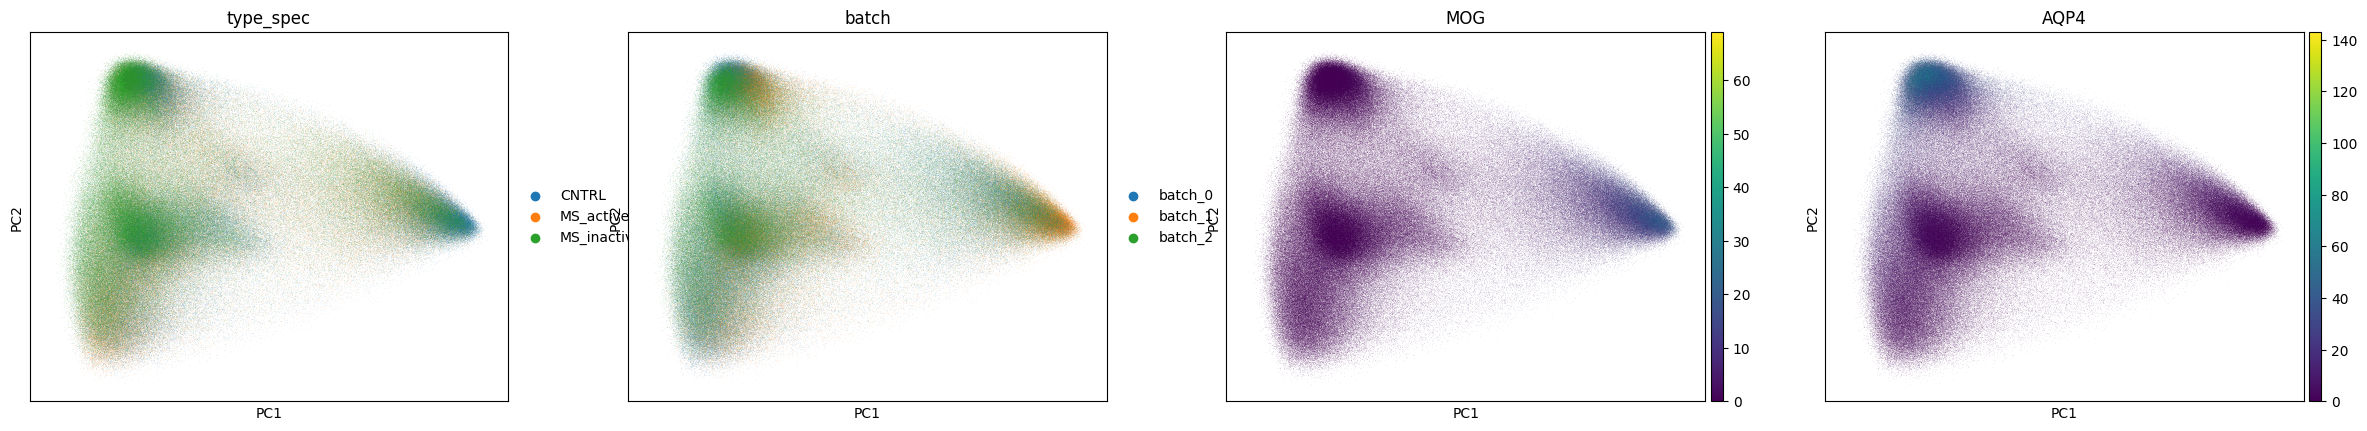

In [3]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True) # save this for later
sc.pl.pca_scatter(adata, color=["type_spec", "batch", "MOG", "AQP4"])

Spatially smooth the PCA coordinates

In [4]:
sq.gr.spatial_neighbors(adata, 
                        spatial_key="spatial",
                        library_key="library_id",
                        coord_type="generic",
                        delaunay=True, 
                        set_diag=True, 
                        radius=[0, 60])

bandwidth = float(np.quantile(adata.obsp["spatial_distances"].data, 0.5))
adata.obsp["spatial_weights"] = adata.obsp["spatial_distances"].copy()
adata.obsp["spatial_weights"].data = np.exp(-adata.obsp["spatial_distances"].data**2 / (2*bandwidth**2))
adata.obsp["spatial_weights"].setdiag(1.0)
adata.obsm["X_pca_spatial"] = adata.obsp["spatial_weights"] @ adata.obsm["X_pca"]

Visualize the weights

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 131789 rows containing missing values.


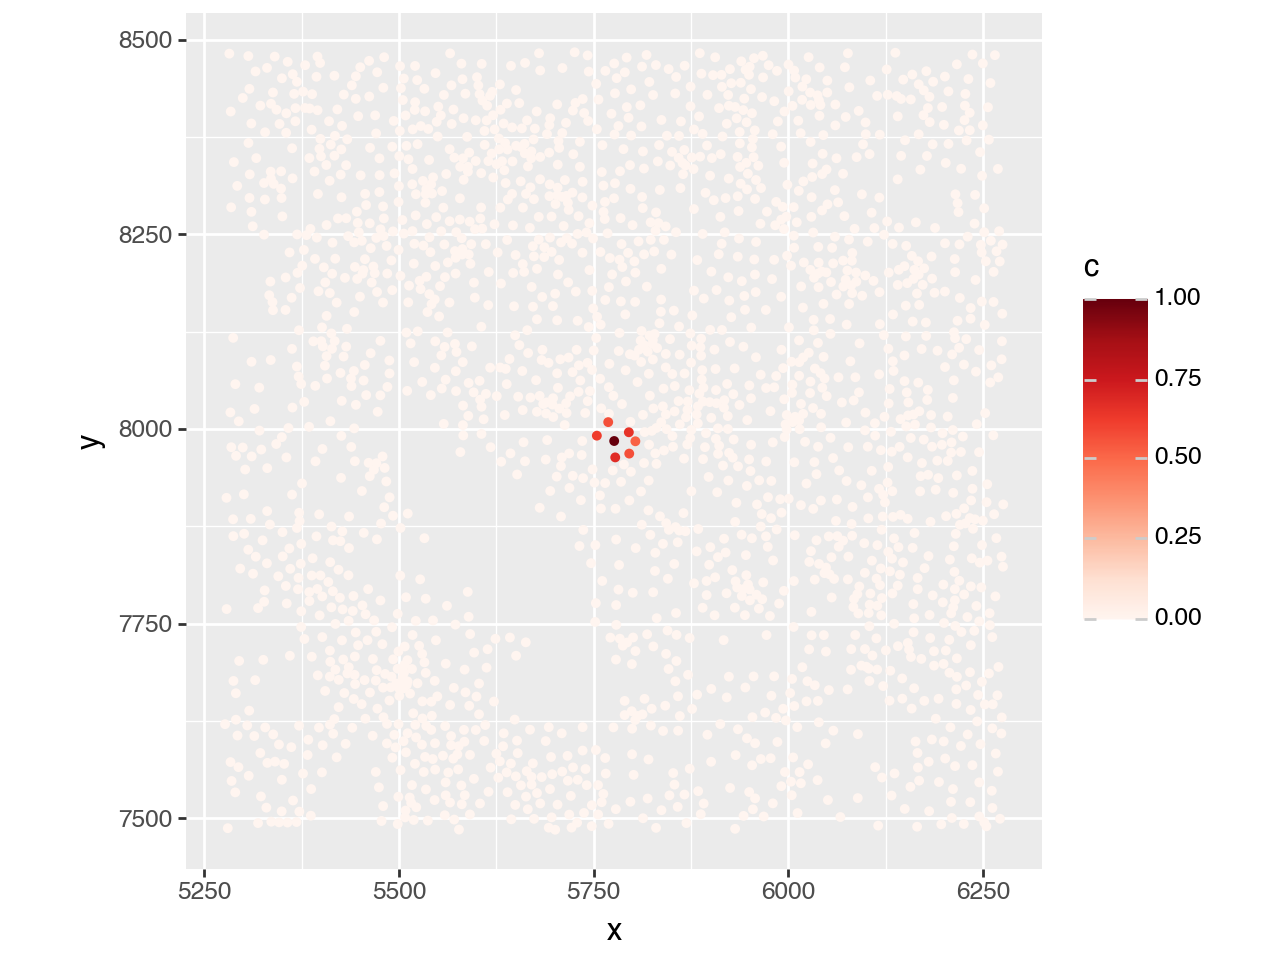

In [5]:
adata_smp = adata[adata.obs["library_id"]=="Active-C_2013-019", :].copy()
idx = 2_000
adata_smp.obs[f"weights_{idx}"] = adata_smp.obsp["spatial_weights"][idx, :].toarray().flatten()

plot_df = pd.DataFrame({
    "x": adata_smp.obsm["spatial"][:, 0],
    "y": adata_smp.obsm["spatial"][:, 1],
    "c": adata_smp.obs[f"weights_{idx}"]
})
plot_df

x_coord = adata_smp.obsm["spatial"][idx, 0]
y_coord = adata_smp.obsm["spatial"][idx, 1]

(pn.ggplot(plot_df) 
 + pn.geom_point(pn.aes(x="x", y="y", color="c"), size=1.0) 
 + pn.lims(x=[x_coord-500, x_coord+500], y=[y_coord-500, y_coord+500]) 
 + pn.scale_color_cmap(cmap_name="Reds")
 + pn.coord_equal())

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. The plot indicates that the gain in explained variance becomes negligible beyond the ninth principal component.

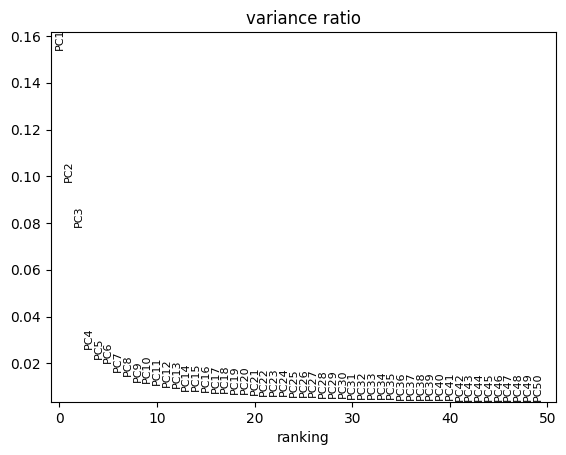

In [6]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

In [7]:
pt.set_obsm(adata=adata, obsm_key="X_pca_spatial", n_dimensions=6)

First we need to determine the number of archetypes. Note that this will take some time since we are talking about 600,000 cells here. Also note that we need to specify `obsm_key="X_pca_spatial"`.

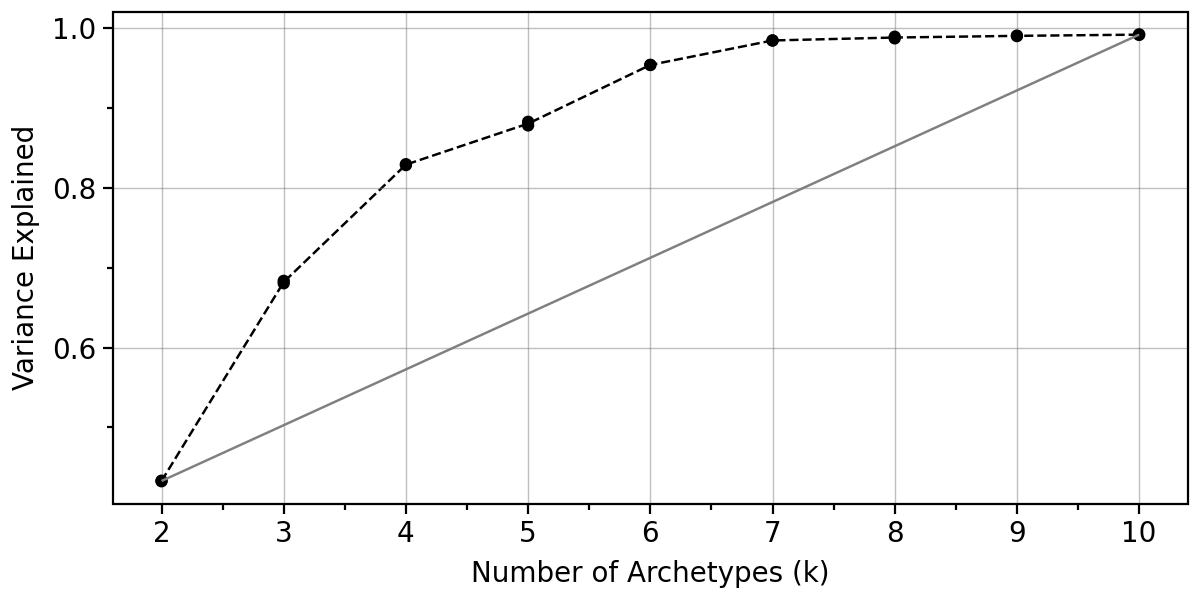

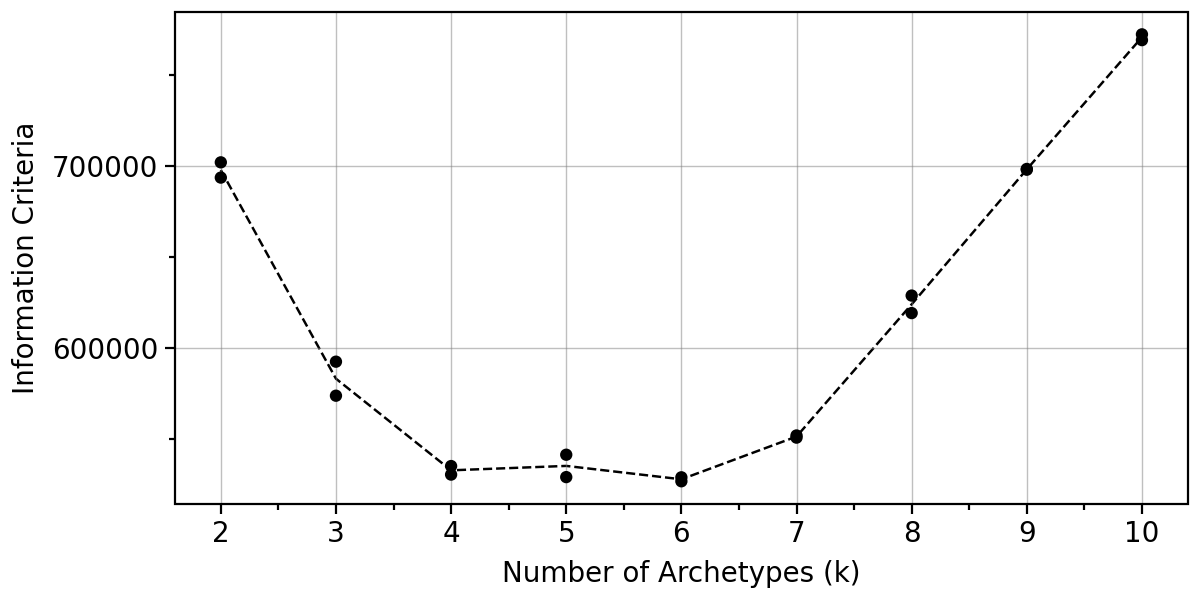

In [8]:
# takes ~3.5 minutes on my macbook
pt.compute_selection_metrics(adata=adata, 
                             min_k=2, max_k=10, 
                             coreset_algorithm="standard",
                             coreset_fraction=0.03, 
                             n_restarts=2)
pt.plot_var_explained(adata).show()
pt.plot_IC(adata).show()

Let us also look at the boostrap variance when using 6 archetypes.

In [9]:
# takes ~3.5 minutes on my macbook
pt.compute_bootstrap_variance(adata=adata, 
                              n_bootstrap=20, 
                              n_archetypes_list=5,
                              coreset_algorithm="standard",
                              coreset_fraction=0.03)

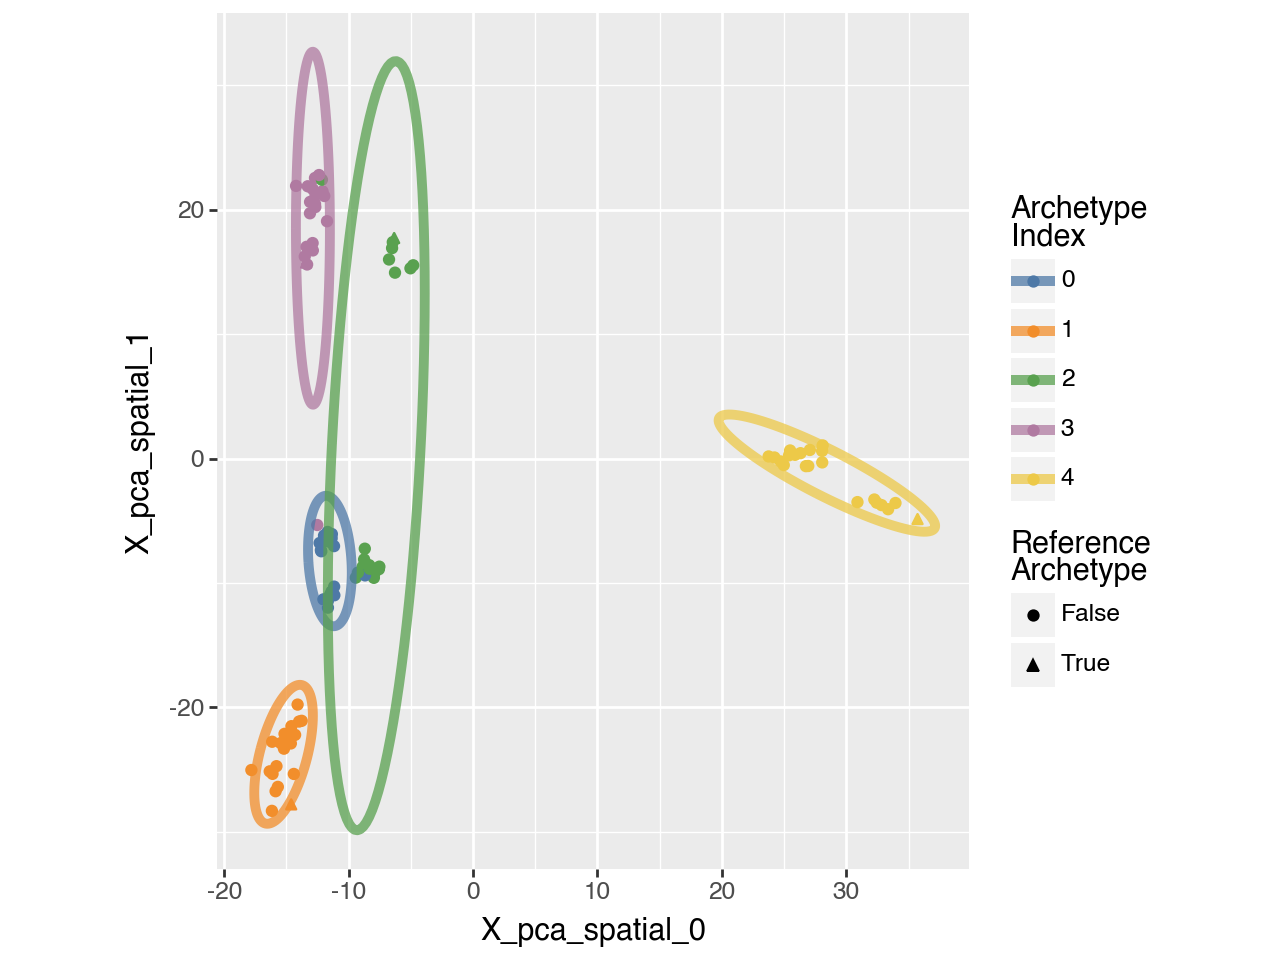

In [10]:
pt.plot_bootstrap_2D(adata, n_archetypes=5)

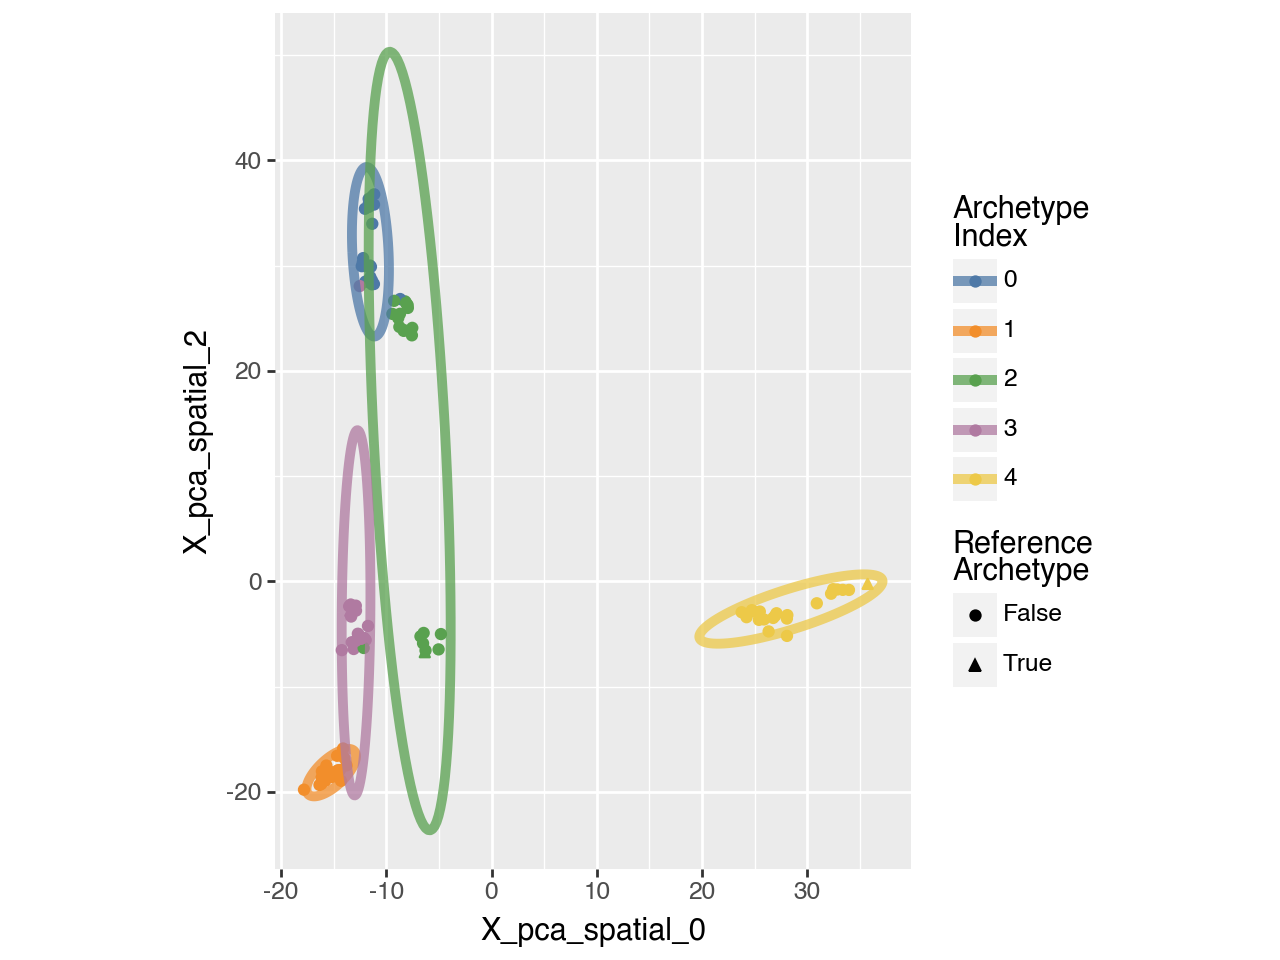

In [11]:
pt.plot_bootstrap_2D(adata, n_archetypes=5, dimensions=[0, 2])

Run archtypal analysis on smoothed PC coordinates

In [12]:
pt.compute_archetypes(adata, 
                      n_archetypes=5, 
                      coreset_algorithm="standard", 
                      coreset_fraction = 0.03)

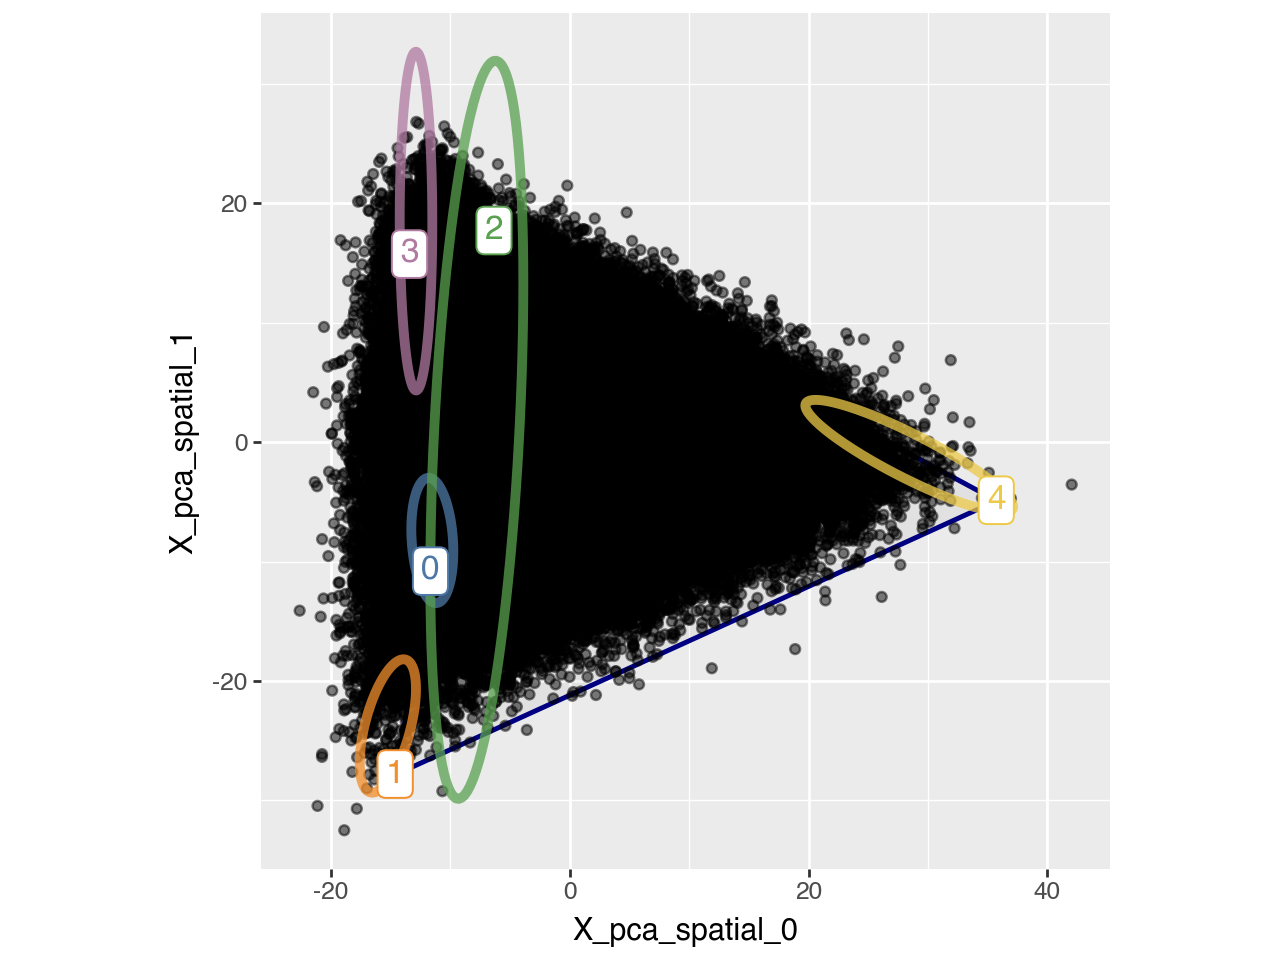

In [13]:
pt.plot_archetypes_2D(adata, show_contours=True)

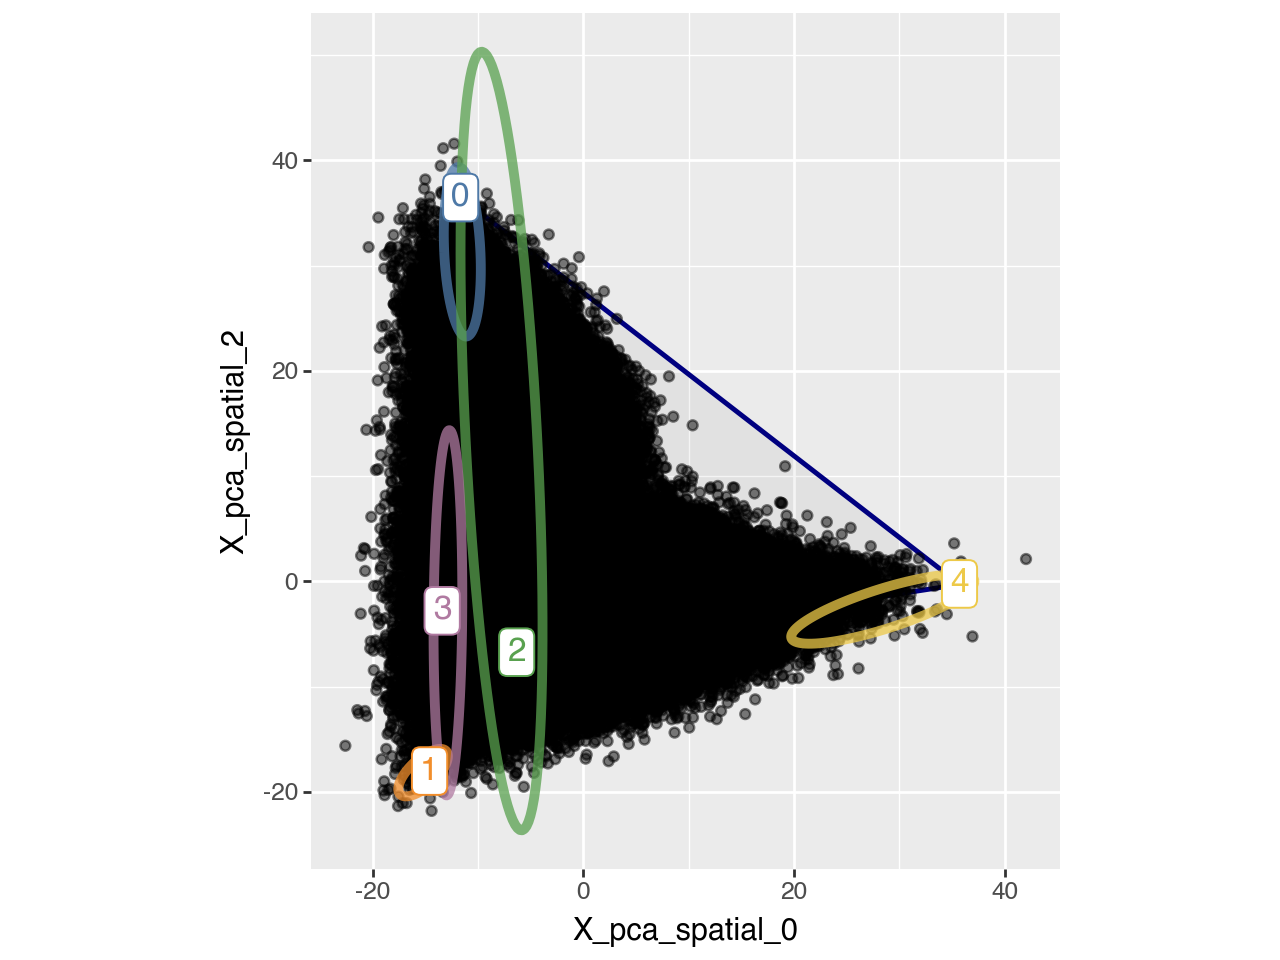

In [14]:
pt.plot_archetypes_2D(adata, show_contours=True, dimensions=[0, 2])

Next we compute the characterisitc gene expression profile for each archetype

In [15]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

Applied length scale is 18.07.


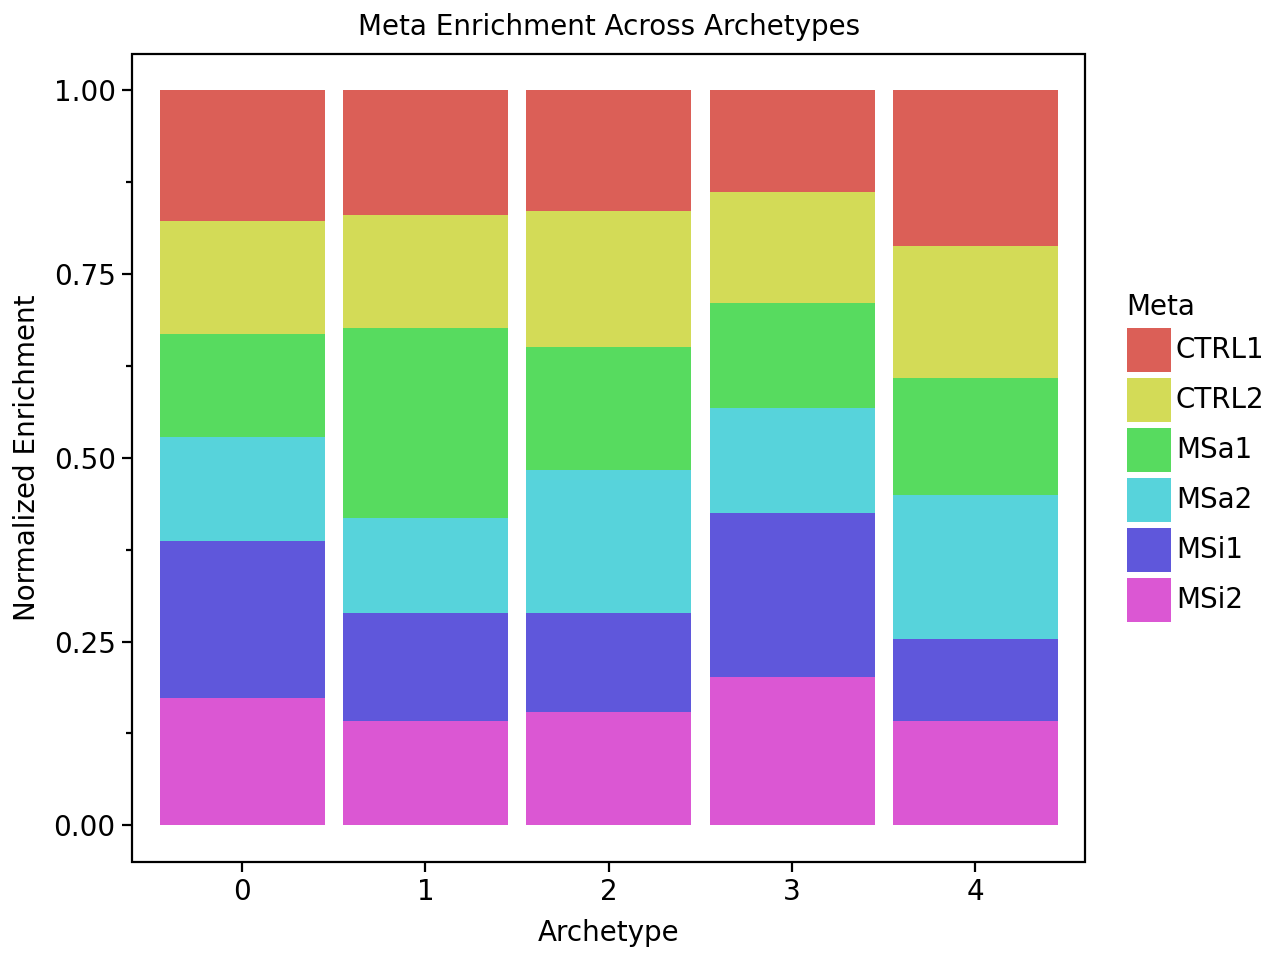

In [16]:
batch_enrichment = pt.compute_meta_enrichment(adata, meta_col="sample_id")
pt.barplot_meta_enrichment(batch_enrichment)

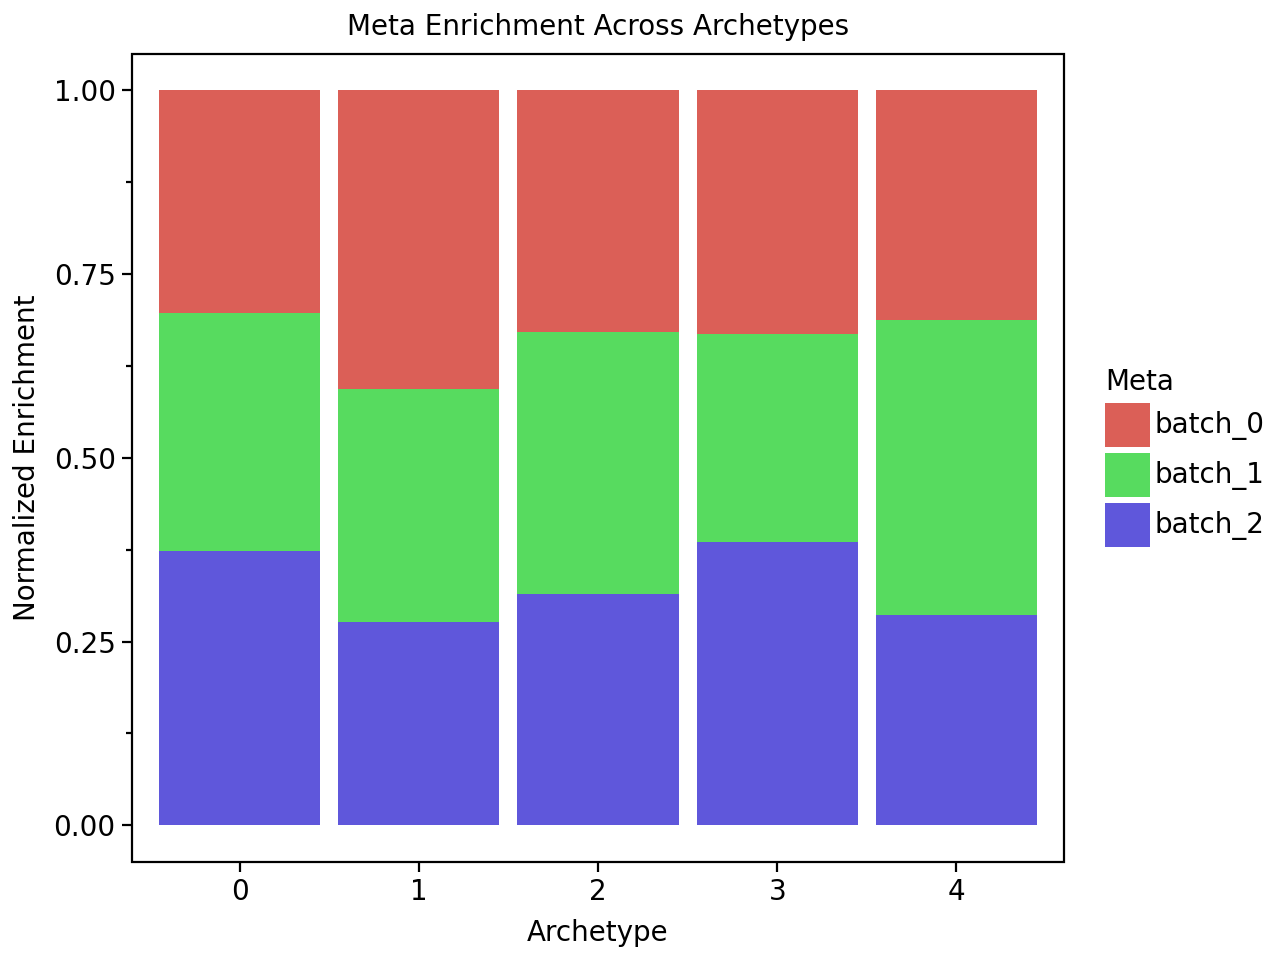

In [17]:
batch_enrichment = pt.compute_meta_enrichment(adata, meta_col="batch")
pt.barplot_meta_enrichment(batch_enrichment)

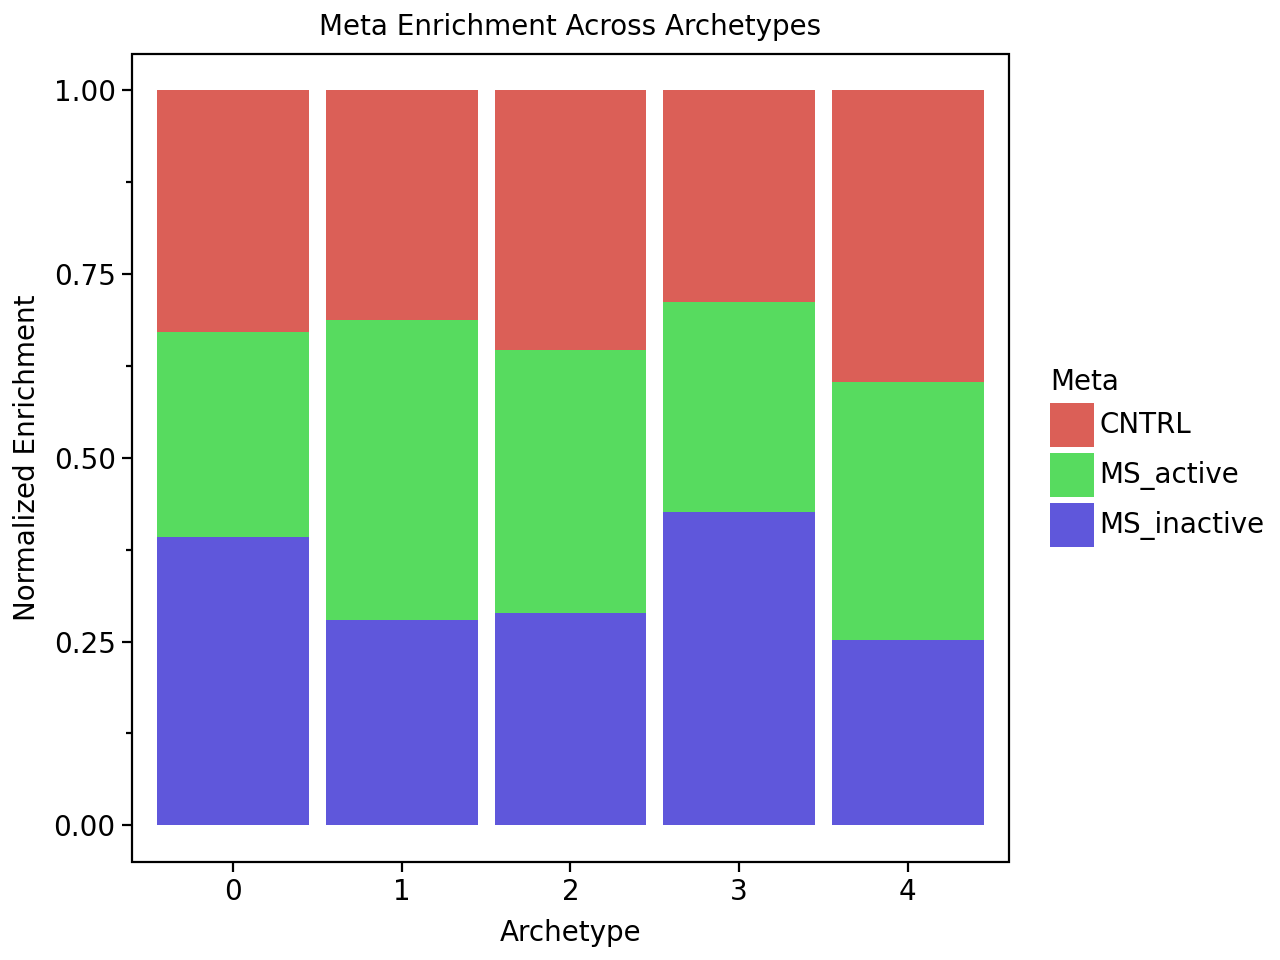

In [18]:
type_spec_enrichment = pt.compute_meta_enrichment(adata, meta_col="type_spec")
pt.barplot_meta_enrichment(type_spec_enrichment)

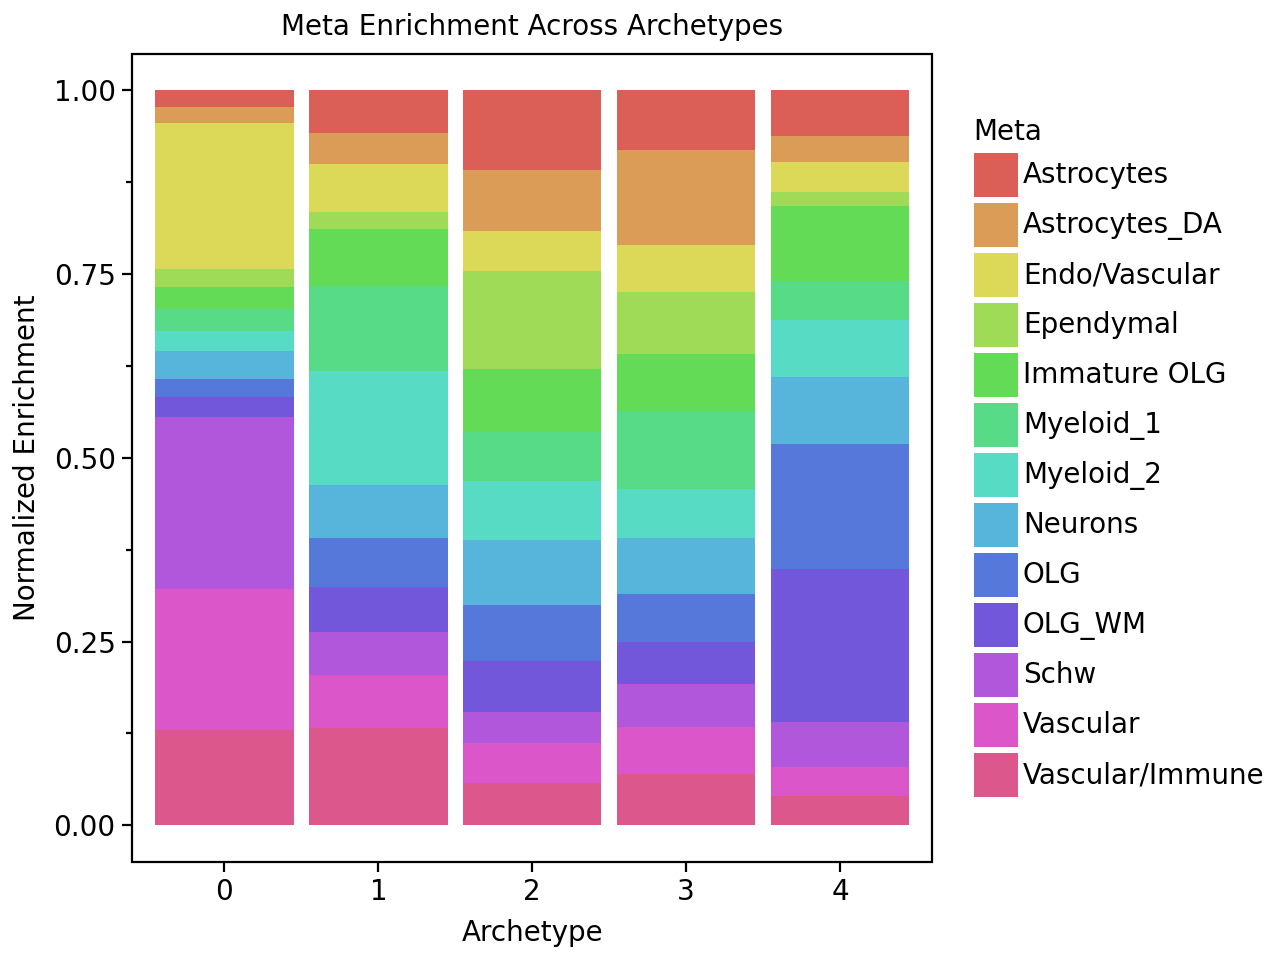

In [19]:
level3_enrichment = pt.compute_meta_enrichment(adata, meta_col="Level1")
pt.barplot_meta_enrichment(level3_enrichment)

## Session Info

In [20]:
import session_info2
print(session_info2.session_info(dependencies=True))

plotnine	0.14.5
requests	2.32.3
scanpy	1.11.2
pandas	2.2.3
numpy	2.2.6
liana	1.5.1
squidpy	1.6.5
partipy	0.0.1
anndata	0.11.4
----	----
jaraco.context	5.3.0
datashader	0.18.1
sphinxcontrib-applehelp	2.0.0
platformdirs	4.3.8
asciitree	0.3.3
sphinxcontrib-serializinghtml	2.0.0
spatial_image	1.2.1
setuptools	80.9.0
jaraco.functools	4.0.1
jupyter_client	8.6.3
stack-data	0.6.3
lazy_loader	0.4
Deprecated	1.2.18
dask-image	2024.5.3
jupyter_core	5.8.1
ipywidgets	8.1.7
cloudpickle	3.1.1
tabulate	0.9.0
comm	0.2.2
matplotlib-inline	0.1.7
llvmlite	0.44.0
PyYAML	6.0.2
scipy	1.15.3
ome-zarr	0.11.1
sphinxcontrib-jsmath	1.0.1
xarray	2025.4.0
jaraco.collections	5.1.0
idna	3.10
pytz	2025.2
more-itertools	10.7.0
numcodecs	0.15.1
rich	14.0.0
tifffile	2025.5.26
h5py	3.13.0
zarr	2.18.7
statsmodels	0.14.4
multipledispatch	1.0.0 (0.6.0)
geopandas	1.0.1
pyarrow	20.0.0
sphinxcontrib-devhelp	2.0.0
executing	2.2.0
dask	2024.11.2
traitlets	5.14.3
docrep	0.3.2
decorator	5.2.1
matplotlib-scalebar	0.9.0
multiscale_sp

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
